# Olist Brazilian E-Commerce Sales Analysis

This notebook analyzes the sales performance of the Olist Brazilian
e-commerce marketplace using the cleaned datasets prepared in
`02_data_cleaning.ipynb`.

The analysis focuses on:

- Overall sales performance
- Revenue and order trends over time
- Product category performance
- Seller performance

## 1. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 2. Load Processed Datasets

Load the cleaned and analysis-ready datasets exported from
`02_data_cleaning.ipynb`.

Only the datasets required for sales analysis are loaded at this stage.

In [2]:
processed_path = Path("../data/processed")

orders = pd.read_csv(
    processed_path / "orders.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

order_items = pd.read_csv(
    processed_path / "order_items.csv",
    parse_dates=["shipping_limit_date"]
)

products = pd.read_csv(
    processed_path / "products.csv"
)

sellers = pd.read_csv(
    processed_path / "sellers.csv"
)

### 2.1 Validate Loaded Datasets

Verify that the processed datasets were loaded successfully and preserve the
expected number of records and columns.

In [3]:
dataset_summary = pd.DataFrame({
    "dataset": [
        "orders",
        "order_items",
        "products",
        "sellers"
    ],
    "rows": [
        len(orders),
        len(order_items),
        len(products),
        len(sellers)
    ],
    "columns": [
        orders.shape[1],
        order_items.shape[1],
        products.shape[1],
        sellers.shape[1]
    ]
})

dataset_summary

,dataset,rows,columns
0,orders,99441,8
1,order_items,112650,7
2,products,32951,10
3,sellers,3095,7


## 3. Sales Metric Definitions

The following definitions are used throughout the sales analysis:

- **Completed Order**: An order with `order_status == "delivered"`.
- **Product Revenue**: Sum of `order_items.price` for completed orders.
- **Freight Value**: Sum of `order_items.freight_value` for completed orders.
- **Total Order Value**: Product revenue plus freight value.
- **Average Order Value (AOV)**: Product revenue divided by the number of
  completed orders.
- **Sales Date**: `order_purchase_timestamp`, representing when the customer
  placed the order.

Only completed orders are included in the core sales KPIs. Other order
statuses remain available in the processed datasets for analyses where they
are relevant.

### 3.1 Create Completed Orders

Core sales metrics are based on completed transactions.

Orders with `order_status == "delivered"` are treated as completed orders.
Other order statuses are preserved in the processed dataset but are excluded
from the core sales metrics.

In [4]:
completed_orders = orders[
    orders["order_status"] == "delivered"
].copy()

print("Completed orders:", len(completed_orders))
print(
    "Unique completed orders:",
    completed_orders["order_id"].nunique()
)

Completed orders: 96478
Unique completed orders: 96478


#### Validation Result

The completed order dataset contains **96,478 delivered orders**.

- All 96,478 records represent successfully delivered orders.
- `order_id` contains **96,478 unique values**, confirming that each completed order appears only once.
- No duplicate `order_id` values were found in the completed order dataset.

This confirms that the dataset is suitable for order-level sales analysis.

### 3.2 Create Sales Item Dataset

Completed orders are joined with order items to create an item-level sales
dataset.

This dataset combines order-level information, such as purchase date, with
item-level information, such as product, seller, price, and freight value.

The resulting dataset contains one record per item within a completed order.

In [5]:
sales_items = order_items.merge(
    completed_orders[
        [
            "order_id",
            "customer_id",
            "order_purchase_timestamp"
        ]
    ],
    on="order_id",
    how="inner",
    validate="many_to_one"
)

sales_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_purchase_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51


In [6]:
print("Sales item records:", len(sales_items))
print("Completed orders with items:", sales_items["order_id"].nunique())
print("Unique products sold:", sales_items["product_id"].nunique())
print("Unique sellers:", sales_items["seller_id"].nunique())

Sales item records: 110197
Completed orders with items: 96478
Unique products sold: 32216
Unique sellers: 2970


#### Sales Item Dataset Validation

The completed sales dataset contains:

- **110,197 item-level sales records**
- **96,478 completed orders**
- **32,216 unique products sold**
- **2,970 active sellers**

The number of item-level records is higher than the number of completed
orders because a single order can contain multiple items.

Therefore, the dataset has an **item-level grain**, while order-level metrics
such as the number of completed orders must be calculated using distinct
`order_id` values.

This distinction is important to prevent double counting when calculating
sales KPIs.

## 4. Overall Sales Performance

This section evaluates the overall sales performance of completed orders
using product revenue, freight value, total order value, completed orders,
and average order value.

In [7]:
product_revenue = sales_items["price"].sum()
freight_value = sales_items["freight_value"].sum()
total_order_value = product_revenue + freight_value

completed_order_count = sales_items["order_id"].nunique()

average_order_value = (
    product_revenue / completed_order_count
)

sales_kpis = pd.DataFrame({
    "Metric": [
        "Product Revenue",
        "Freight Value",
        "Total Order Value",
        "Completed Orders",
        "Average Order Value"
    ],
    "Value": [
        product_revenue,
        freight_value,
        total_order_value,
        completed_order_count,
        average_order_value
    ]
})

sales_kpis

,Metric,Value
0,Product Revenue,1.322150e+07
1,Freight Value,2.198276e+06
2,Total Order Value,1.541977e+07
3,Completed Orders,9.647800e+04
4,Average Order Value,1.370416e+02


In [8]:
sales_kpi_display = pd.DataFrame({
    "Metric": [
        "Product Revenue",
        "Freight Value",
        "Total Order Value",
        "Completed Orders",
        "Average Order Value"
    ],
    "Value": [
        f"R$ {product_revenue:,.2f}",
        f"R$ {freight_value:,.2f}",
        f"R$ {total_order_value:,.2f}",
        f"{completed_order_count:,}",
        f"R$ {average_order_value:,.2f}"
    ]
})

sales_kpi_display

,Metric,Value
0,Product Revenue,"R$ 13,221,498.11"
1,Freight Value,"R$ 2,198,275.64"
2,Total Order Value,"R$ 15,419,773.75"
3,Completed Orders,"96,478"
4,Average Order Value,R$ 137.04


### Overall Sales Performance — Key Findings

The completed-order analysis shows that Olist generated approximately
**R$13.22 million in product revenue** across **96,478 completed orders**.

- Product revenue reached approximately **R$13.22 million**.
- Freight charges contributed an additional **R$2.20 million**.
- The combined order value, including freight, was approximately
  **R$15.42 million**.
- A total of **96,478 orders** were successfully completed.
- The average product revenue per completed order was approximately
  **R$137.04**.

These metrics establish the overall sales baseline for the following
time-series, product category, and seller performance analyses.

## 5. Sales Trend Analysis

This section analyzes how Olist's sales performance changed over time.

Monthly product revenue and completed orders are used to identify sales
trends, growth patterns, and periods of unusually high or low performance.

### 5.1 Prepare Monthly Sales Data

The `order_purchase_timestamp` is converted to a monthly period to analyze
sales performance over time.

Monthly aggregation allows revenue and order volume to be compared
consistently across the dataset.

In [9]:
sales_items["purchase_month"] = (
    sales_items["order_purchase_timestamp"]
    .dt.to_period("M")
)

sales_items[
    ["order_purchase_timestamp", "purchase_month"]
].head()

,order_purchase_timestamp,purchase_month
0,2017-09-13 08:59:02,2017-09
1,2017-04-26 10:53:06,2017-04
2,2018-01-14 14:33:31,2018-01
3,2018-08-08 10:00:35,2018-08
4,2017-02-04 13:57:51,2017-02


### 5.2 Monthly Revenue and Orders

Monthly product revenue and completed orders are aggregated to evaluate
changes in sales value and order volume over time.

In [10]:
monthly_sales = (
    sales_items
    .groupby("purchase_month")
    .agg(
        product_revenue=("price", "sum"),
        completed_orders=("order_id", "nunique")
    )
    .reset_index()
)

monthly_sales

,purchase_month,product_revenue,completed_orders
0,2016-09,134.97,1
1,2016-10,40325.11,265
2,2016-12,10.90,1
3,2017-01,111798.36,750
4,2017-02,234223.40,1653
5,2017-03,359198.85,2546
6,2017-04,340669.68,2303
7,2017-05,489338.25,3546
8,2017-06,421923.37,3135
9,2017-07,481604.52,3872


#### Initial Monthly Sales Observation

The monthly sales data covers the period from **September 2016 to August 2018**.
However, the earliest months show unusually sparse transaction activity.

- **September 2016** contains only **1 completed order**, generating **R$134.97** in product revenue.
- **October 2016** contains **265 completed orders**, generating **R$40,325.11** in product revenue.
- **November 2016** does not appear in the monthly sales results, indicating no completed sales records for that month.
- **December 2016** again contains only **1 completed order**, generating **R$10.90** in product revenue.
- Transaction volume increases substantially beginning in **January 2017**.

These observations suggest that the early 2016 period contains very limited
transaction coverage and may not be directly comparable with the more active
sales periods in 2017 and 2018.

Therefore, the early months should be examined separately before interpreting
the overall sales trend. This helps avoid incorrectly treating differences in
data coverage as actual business growth.

### 5.3 Validate Monthly Coverage

Before interpreting the monthly sales trend, the dataset is examined for
potential gaps and unusually sparse periods.

This validation focuses on:

- The contribution of each month to total product revenue
- The overall monthly coverage of the dataset
- Missing months within the observed sales period

This helps distinguish actual sales performance from potential differences
in data coverage.

#### Calculate revenue_share

In [11]:
monthly_sales["revenue_share"] = (
    monthly_sales["product_revenue"]
    / monthly_sales["product_revenue"].sum()
    * 100
)

monthly_sales[
    [
        "purchase_month",
        "product_revenue",
        "completed_orders",
        "revenue_share"
    ]
].head(5)

,purchase_month,product_revenue,completed_orders,revenue_share
0,2016-09,134.97,1,0.001021
1,2016-10,40325.11,265,0.304997
2,2016-12,10.90,1,0.000082
3,2017-01,111798.36,750,0.845580
4,2017-02,234223.40,1653,1.771534


#### Check for missing months

In [12]:
full_month_range = pd.period_range(
    start=monthly_sales["purchase_month"].min(),
    end=monthly_sales["purchase_month"].max(),
    freq="M"
)

missing_months = full_month_range.difference(
    monthly_sales["purchase_month"]
)

print("First month:", monthly_sales["purchase_month"].min())
print("Last month:", monthly_sales["purchase_month"].max())
print("Number of observed months:", len(monthly_sales))
print("Expected number of months:", len(full_month_range))
print("Missing months:", list(missing_months))

First month: 2016-09
Last month: 2018-08
Number of observed months: 23
Expected number of months: 24
Missing months: [Period('2016-11', 'M')]


#### Check 2016 early_period

In [13]:
early_period = monthly_sales[
    monthly_sales["purchase_month"] < "2017-01"
].copy()

early_period

,purchase_month,product_revenue,completed_orders,revenue_share
0,2016-09,134.97,1,0.001021
1,2016-10,40325.11,265,0.304997
2,2016-12,10.90,1,0.000082


#### Validate Transaction Date Coverage

In [14]:
completed_sales_date_range = sales_items[
    "order_purchase_timestamp"
].agg(["min", "max"])

completed_sales_date_range

min   2016-09-15 12:16:38
max   2018-08-29 15:00:37
Name: order_purchase_timestamp, dtype: datetime64[us]

#### Monthly Coverage Validation — Key Findings

The completed-sales data spans from **September 15, 2016 to August 29, 2018**,
with sales activity observed across 23 of the 24 calendar months within this
range.

The early transaction period is particularly sparse:

- **September 2016:** 1 completed order and R$134.97 in product revenue
  (approximately 0.001% of total product revenue).
- **October 2016:** 265 completed orders and R$40,325.11 in product revenue
  (approximately 0.305% of total product revenue).
- **November 2016:** No completed sales records.
- **December 2016:** 1 completed order and R$10.90 in product revenue
  (less than 0.001% of total product revenue).

Together, the observed months before January 2017 account for only
approximately **0.31% of total product revenue**.

These results indicate that the 2016 observations represent a very sparse
early data period and are not directly comparable with the substantially
higher transaction activity observed from 2017 onward.

Therefore, **January 2017 through August 2018** is used as the primary period
for monthly sales trend analysis. The 2016 records remain preserved in the
underlying dataset and are excluded only from the main trend comparison.

The final observed completed sale occurred on **August 29, 2018**. Therefore,
August 2018 is retained in the analysis, but results for the final month
should be interpreted with some caution because the observed completed-sales
data does not extend through the final two calendar days of the month.

### 5.4 Define the Main Analysis Period

Based on the monthly coverage validation, the primary sales trend analysis
focuses on the period from **January 2017 through August 2018**.

The sparse 2016 observations remain preserved in the underlying dataset but
are excluded from the main trend analysis to improve comparability across
months.

In [15]:
monthly_sales_main = monthly_sales[
    monthly_sales["purchase_month"] >= "2017-01"
].copy()

monthly_sales_main[
    [
        "purchase_month",
        "product_revenue",
        "completed_orders"
    ]
]

,purchase_month,product_revenue,completed_orders
3,2017-01,111798.36,750
4,2017-02,234223.40,1653
5,2017-03,359198.85,2546
6,2017-04,340669.68,2303
7,2017-05,489338.25,3546
8,2017-06,421923.37,3135
9,2017-07,481604.52,3872
10,2017-08,554699.70,4193
11,2017-09,607399.67,4150
12,2017-10,648247.65,4478


In [16]:
print("Main analysis start:", monthly_sales_main["purchase_month"].min())
print("Main analysis end:", monthly_sales_main["purchase_month"].max())
print("Number of months:", len(monthly_sales_main))

Main analysis start: 2017-01
Main analysis end: 2018-08
Number of months: 20


### 5.5 Monthly Product Revenue Trend

Monthly product revenue is visualized across the main analysis period to
identify overall sales patterns, periods of growth, and changes in marketplace
performance over time.

In [17]:
monthly_sales_main["month"] = (
    monthly_sales_main["purchase_month"]
    .dt.to_timestamp()
)

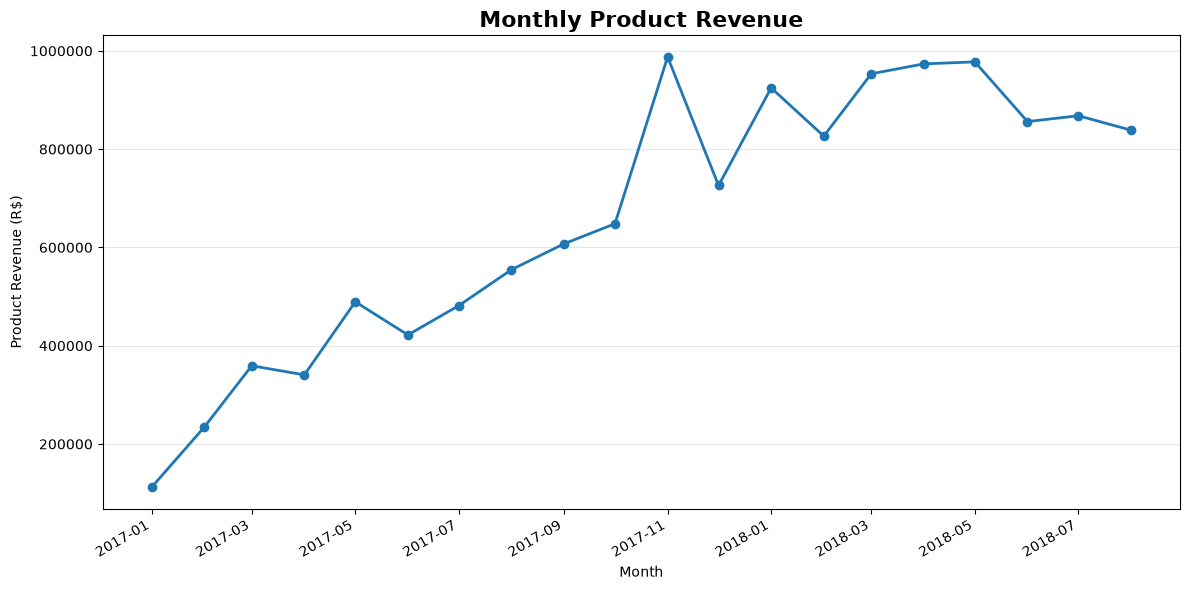

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    monthly_sales_main["month"],
    monthly_sales_main["product_revenue"],
    marker="o",
    linewidth=2
)

ax.set_title(
    "Monthly Product Revenue",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Month")
ax.set_ylabel("Product Revenue (R$)")

ax.ticklabel_format(
    style="plain",
    axis="y"
)

ax.grid(
    axis="y",
    alpha=0.3
)

fig.autofmt_xdate()

plt.tight_layout()
plt.show()

### 5.6 Identify Peak and Lowest Revenue Months

The highest- and lowest-revenue months within the main analysis period are
identified to quantify the most notable points in the monthly sales trend.

In [19]:
highest_revenue_month = monthly_sales_main.loc[
    monthly_sales_main["product_revenue"].idxmax()
]

lowest_revenue_month = monthly_sales_main.loc[
    monthly_sales_main["product_revenue"].idxmin()
]

print("Highest Revenue Month")
print(
    highest_revenue_month[
        ["purchase_month", "product_revenue", "completed_orders"]
    ]
)

print("\nLowest Revenue Month")
print(
    lowest_revenue_month[
        ["purchase_month", "product_revenue", "completed_orders"]
    ]
)

Highest Revenue Month
purchase_month        2017-11
product_revenue     987765.37
completed_orders         7289
Name: 13, dtype: object

Lowest Revenue Month
purchase_month        2017-01
product_revenue     111798.36
completed_orders          750
Name: 3, dtype: object


#### Monthly Revenue Trend — Key Findings

During the main analysis period from **January 2017 to August 2018**, monthly
product revenue increased substantially compared with the beginning of the
period, although month-to-month fluctuations were present.

- **January 2017** recorded the lowest monthly product revenue at
  **R$111,798.36**, with **750 completed orders**.
- **November 2017** recorded the highest monthly product revenue at
  **R$987,765.37**, with **7,289 completed orders**.
- Product revenue in the peak month was approximately **7.8 times** the level
  recorded in January 2017.
- The peak in November 2017 was accompanied by the highest observed order
  volume among these two comparison points, suggesting that increased order
  activity was an important contributor to the revenue peak.

Overall, the results indicate substantial expansion in sales activity during
2017. However, monthly revenue did not increase continuously, so
month-over-month growth should be examined before drawing conclusions about
the consistency of the sales trend.

### 5.7 Month-over-Month Revenue Growth

Month-over-month (MoM) revenue growth measures the percentage change in
product revenue compared with the previous month.

This metric helps identify periods of rapid sales expansion or contraction
that may not be immediately apparent from the overall revenue trend.

In [20]:
monthly_sales_main["revenue_mom_growth"] = (
    monthly_sales_main["product_revenue"]
    .pct_change()
    * 100
)

monthly_sales_main[
    [
        "purchase_month",
        "product_revenue",
        "revenue_mom_growth"
    ]
]

,purchase_month,product_revenue,revenue_mom_growth
3,2017-01,111798.36,NaN
4,2017-02,234223.40,109.505220
5,2017-03,359198.85,53.357372
6,2017-04,340669.68,-5.158471
7,2017-05,489338.25,43.640094
8,2017-06,421923.37,-13.776744
9,2017-07,481604.52,14.145021
10,2017-08,554699.70,15.177428
11,2017-09,607399.67,9.500631
12,2017-10,648247.65,6.725058


In [21]:
highest_growth_month = monthly_sales_main.loc[
    monthly_sales_main["revenue_mom_growth"].idxmax()
]

largest_decline_month = monthly_sales_main.loc[
    monthly_sales_main["revenue_mom_growth"].idxmin()
]

print("Highest MoM Revenue Growth")
print(
    highest_growth_month[
        [
            "purchase_month",
            "product_revenue",
            "revenue_mom_growth"
        ]
    ]
)

print("\nLargest MoM Revenue Decline")
print(
    largest_decline_month[
        [
            "purchase_month",
            "product_revenue",
            "revenue_mom_growth"
        ]
    ]
)

Highest MoM Revenue Growth
purchase_month          2017-02
product_revenue        234223.4
revenue_mom_growth    109.50522
Name: 4, dtype: object

Largest MoM Revenue Decline
purchase_month          2017-12
product_revenue       726033.19
revenue_mom_growth   -26.497404
Name: 14, dtype: object


#### Month-over-Month Revenue Growth — Key Findings

The month-over-month analysis shows that revenue growth was uneven across the
main analysis period.

- **February 2017** recorded the strongest month-over-month revenue growth at
  approximately **109.5%**, with product revenue increasing to
  **R$234,223.40**.
- **December 2017** recorded the largest month-over-month decline at
  approximately **-26.5%**, with product revenue decreasing to
  **R$726,033.19**.
- The strong growth in February 2017 occurred early in the main analysis
  period, when the marketplace was still operating at a relatively low sales
  base.
- The decline in December 2017 followed the revenue peak observed in
  November 2017, indicating that the November peak was not sustained into the
  following month.

Overall, monthly revenue growth was volatile rather than continuous. This
indicates that Olist experienced substantial overall sales expansion alongside
meaningful short-term monthly fluctuations.

### 5.8 Monthly Completed Orders Trend

Monthly completed orders are analyzed to determine whether changes in product
revenue are associated with changes in order volume.

Comparing the order trend with the revenue trend helps distinguish whether
sales growth is primarily driven by a larger number of completed orders or
by changes in the revenue generated per order.

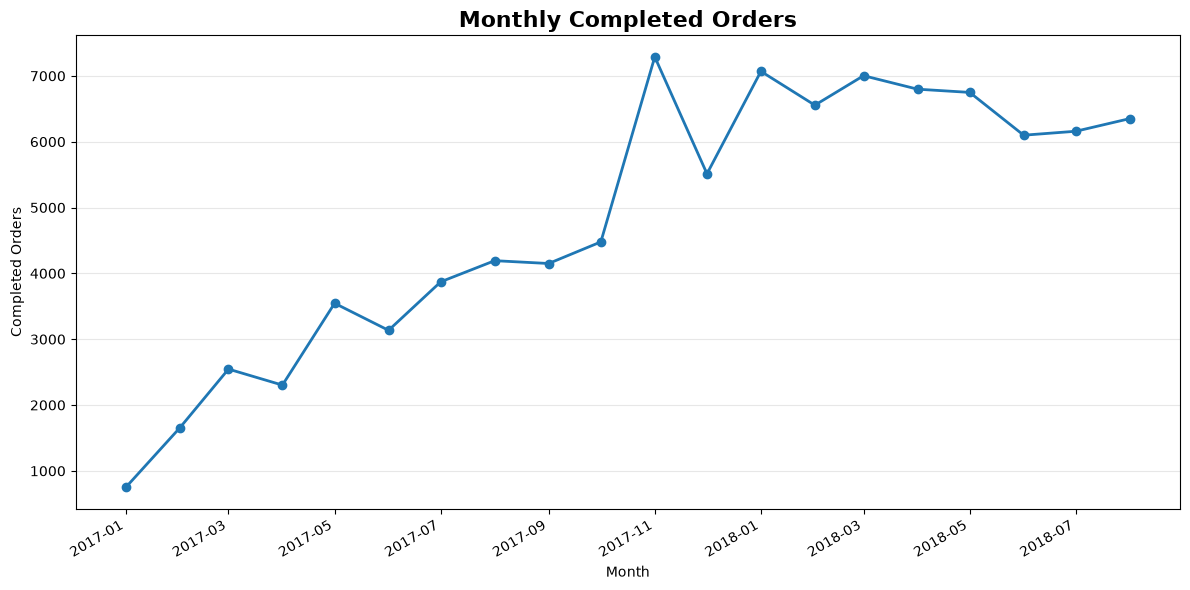

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    monthly_sales_main["month"],
    monthly_sales_main["completed_orders"],
    marker="o",
    linewidth=2
)

ax.set_title(
    "Monthly Completed Orders",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Month")
ax.set_ylabel("Completed Orders")

ax.grid(
    axis="y",
    alpha=0.3
)

fig.autofmt_xdate()

plt.tight_layout()
plt.show()

#### Find the highest and lowest order months

In [23]:
highest_order_month = monthly_sales_main.loc[
    monthly_sales_main["completed_orders"].idxmax()
]

lowest_order_month = monthly_sales_main.loc[
    monthly_sales_main["completed_orders"].idxmin()
]

print("Highest Completed Orders Month")
print(
    highest_order_month[
        [
            "purchase_month",
            "completed_orders",
            "product_revenue"
        ]
    ]
)

print("\nLowest Completed Orders Month")
print(
    lowest_order_month[
        [
            "purchase_month",
            "completed_orders",
            "product_revenue"
        ]
    ]
)

Highest Completed Orders Month
purchase_month        2017-11
completed_orders         7289
product_revenue     987765.37
Name: 13, dtype: object

Lowest Completed Orders Month
purchase_month        2017-01
completed_orders          750
product_revenue     111798.36
Name: 3, dtype: object


#### Calculate Monthly AOV

In [24]:
monthly_sales_main["average_order_value"] = (
    monthly_sales_main["product_revenue"]
    / monthly_sales_main["completed_orders"]
)

monthly_sales_main[
    [
        "purchase_month",
        "product_revenue",
        "completed_orders",
        "average_order_value"
    ]
]

,purchase_month,product_revenue,completed_orders,average_order_value
3,2017-01,111798.36,750,149.064480
4,2017-02,234223.40,1653,141.695947
5,2017-03,359198.85,2546,141.083602
6,2017-04,340669.68,2303,147.924307
7,2017-05,489338.25,3546,137.997250
8,2017-06,421923.37,3135,134.584807
9,2017-07,481604.52,3872,124.381333
10,2017-08,554699.70,4193,132.291844
11,2017-09,607399.67,4150,146.361366
12,2017-10,648247.65,4478,144.762762


#### Find the highest and lowest months for AOV.

In [25]:
highest_aov_month = monthly_sales_main.loc[
    monthly_sales_main["average_order_value"].idxmax()
]

lowest_aov_month = monthly_sales_main.loc[
    monthly_sales_main["average_order_value"].idxmin()
]

print("Highest AOV Month")
print(
    highest_aov_month[
        [
            "purchase_month",
            "average_order_value",
            "completed_orders",
            "product_revenue"
        ]
    ]
)

print("\nLowest AOV Month")
print(
    lowest_aov_month[
        [
            "purchase_month",
            "average_order_value",
            "completed_orders",
            "product_revenue"
        ]
    ]
)

Highest AOV Month
purchase_month           2017-01
average_order_value    149.06448
completed_orders             750
product_revenue        111798.36
Name: 3, dtype: object

Lowest AOV Month
purchase_month            2017-07
average_order_value    124.381333
completed_orders             3872
product_revenue         481604.52
Name: 9, dtype: object


#### Monthly Orders and Average Order Value — Key Findings

Monthly completed orders closely reflect the major movements observed in
product revenue during the main analysis period.

- **January 2017** recorded the lowest order volume, with **750 completed
  orders** and **R$111,798.36** in product revenue.
- **November 2017** recorded the highest order volume, with **7,289 completed
  orders** and **R$987,765.37** in product revenue.
- The lowest and highest order-volume months therefore coincide with the
  lowest and highest revenue months, respectively.
- In contrast, **January 2017 recorded the highest monthly AOV at
  approximately R$149.06**, despite having the lowest revenue and order
  volume.
- The lowest monthly AOV was approximately **R$124.38 in July 2017**.

These results suggest that the substantial increase in monthly product
revenue was more strongly associated with growth in completed order volume
than with increases in revenue per order.

In other words, Olist's sales expansion was more closely associated with
higher completed order volume, while average order value remained within a
comparatively narrower range.

### 5.9 Revenue and Order Volume Relationship

To further evaluate whether monthly revenue changes are associated with order
volume, the correlation between monthly product revenue and completed orders
is calculated.

A strong positive correlation would provide additional evidence that changes
in sales revenue are closely related to changes in the number of completed
orders.

In [26]:
revenue_order_correlation = (
    monthly_sales_main[
        ["product_revenue", "completed_orders"]
    ]
    .corr()
    .loc["product_revenue", "completed_orders"]
)

print(
    "Correlation between Product Revenue and Completed Orders:",
    round(revenue_order_correlation, 4)
)

Correlation between Product Revenue and Completed Orders: 0.9927


#### Revenue and Order Volume Relationship — Key Finding

Monthly product revenue and completed orders show a **very strong positive
correlation of 0.9927** during the main analysis period.

This indicates that months with higher completed order volumes generally also
generated higher product revenue.

Combined with the previous findings, the results provide strong evidence that
Olist's monthly revenue expansion was closely associated with increasing order
volume rather than substantial increases in average order value.

However, correlation represents an association rather than causation.
Therefore, the result should not be interpreted as proof that higher order
volume alone caused the observed revenue growth.

### 5.10 Sales Trend Analysis Summary

The monthly sales analysis reveals a substantial expansion in Olist's sales
activity during the main analysis period from **January 2017 to August 2018**.

Key findings include:

- Monthly product revenue expanded substantially during 2017, rising from
  **R$111,798.36 in January 2017** to a peak of **R$987,765.37 in November
  2017**, despite several month-to-month declines along the way.
- Completed orders increased from **750 in January 2017** to a peak of
  **7,289 in November 2017**.
- The strongest month-over-month revenue growth occurred in **February 2017**
  at approximately **109.5%**, while the largest decline occurred in
  **December 2017** at approximately **-26.5%**.
- Monthly AOV ranged from approximately **R$124.38 to R$149.06**, a much
  narrower variation compared with the substantial change in monthly order
  volume.
- Product revenue and completed orders showed a **very strong positive
  correlation of 0.9927**.

Overall, the evidence suggests that Olist's sales expansion was more closely
associated with increasing completed order volume than with sustained growth
in average order value.

The monthly trend was not continuously upward, however, as several periods
experienced short-term revenue declines. This indicates that the marketplace
combined substantial overall expansion with meaningful month-to-month
fluctuations.

The final observed completed sale occurred on **August 29, 2018**, so results
for August 2018 should be interpreted with some caution when comparing the
final month with earlier periods.

## 6. Product Category Performance

This section evaluates sales performance across product categories to identify
which categories contribute the most to Olist's completed-order revenue.

The analysis focuses on:

- Product revenue by category
- Completed orders by category
- Number of items sold
- Revenue contribution by category
- Differences between revenue ranking and order-volume ranking

Only completed-order sales are included to maintain consistency with the core
sales metrics defined earlier.

### 6.1 Create Category Sales Dataset

Product category information is added to the completed item-level sales
dataset using `product_id`.

Before merging, the relevant product fields and key uniqueness are validated
to ensure that each product maps to only one product record and that the merge
does not multiply sales records.

In [27]:
products[
    [
        "product_id",
        "product_category_name",
        "product_category_name_english"
    ]
].head()

,product_id,product_category_name,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares


In [28]:
print("Product records:", len(products))
print("Unique product IDs:", products["product_id"].nunique())
print(
    "Duplicate product IDs:",
    products["product_id"].duplicated().sum()
)

Product records: 32951
Unique product IDs: 32951
Duplicate product IDs: 0


#### Product Key Validation — Key Findings

The `products` dataset contains **32,951 product records** and **32,951 unique
product IDs**, with no duplicate `product_id` values.

This confirms that each product maps to a single product record and that
`product_id` can be safely used as the key for a many-to-one merge with the
completed item-level sales dataset.

### 6.2 Merge Product Category Information

Product category information is added to the completed item-level sales
dataset using `product_id`.

A many-to-one relationship is expected because multiple sales items may refer
to the same product, while each `product_id` appears only once in the product
table.

In [29]:
category_sales = sales_items.merge(
    products[
        [
            "product_id",
            "product_category_name",
            "product_category_name_english"
        ]
    ],
    on="product_id",
    how="left",
    validate="many_to_one"
)

category_sales.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_purchase_timestamp,purchase_month,product_category_name,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,2017-09,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,2017-04,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,2018-01,moveis_decoracao,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,2018-08,perfumaria,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,2017-02,ferramentas_jardim,garden_tools


### 6.3 Validate Category Merge

The merged dataset is validated to confirm that adding product category
information does not change the number of completed item-level sales records
or introduce row multiplication through the join.

In [30]:
print("Sales item records before merge:", len(sales_items))
print("Sales item records after merge:", len(category_sales))

print(
    "Missing English category:",
    category_sales["product_category_name_english"].isna().sum()
)

print(
    "Unique English categories:",
    category_sales["product_category_name_english"].nunique()
)

Sales item records before merge: 110197
Sales item records after merge: 110197
Missing English category: 0
Unique English categories: 72


#### Category Merge Validation — Key Findings

The category merge preserved all **110,197 completed item-level sales records**,
with the row count remaining unchanged before and after the merge.

No missing English product categories were found after the join, indicating
that every completed sales item has an available category label for analysis.

The merged dataset contains **72 unique English product categories**.

These results confirm that the product-category merge preserved the original
item-level grain without introducing row multiplication or losing completed
sales records. The dataset is therefore suitable for category-level sales
analysis.

In [31]:
sorted(
    category_sales["product_category_name_english"].unique()
)

['agro_industry_and_commerce',
 'air_conditioning',
 'art',
 'arts_and_craftmanship',
 'audio',
 'auto',
 'baby',
 'bed_bath_table',
 'books_general_interest',
 'books_imported',
 'books_technical',
 'cds_dvds_musicals',
 'christmas_supplies',
 'cine_photo',
 'computers',
 'computers_accessories',
 'consoles_games',
 'construction_tools_construction',
 'construction_tools_lights',
 'construction_tools_safety',
 'cool_stuff',
 'costruction_tools_garden',
 'costruction_tools_tools',
 'diapers_and_hygiene',
 'drinks',
 'dvds_blu_ray',
 'electronics',
 'fashio_female_clothing',
 'fashion_bags_accessories',
 'fashion_childrens_clothes',
 'fashion_male_clothing',
 'fashion_shoes',
 'fashion_sport',
 'fashion_underwear_beach',
 'fixed_telephony',
 'flowers',
 'food',
 'food_drink',
 'furniture_bedroom',
 'furniture_decor',
 'furniture_living_room',
 'furniture_mattress_and_upholstery',
 'garden_tools',
 'health_beauty',
 'home_appliances',
 'home_appliances_2',
 'home_comfort_2',
 'home_confo

### 6.4 Product Revenue by Category

Product revenue is aggregated by English product category to identify the
categories that contribute the most to completed-order sales.

The `unknown` category is retained because it represents valid completed sales
whose original product category could not be identified. It is treated as an
unclassified group rather than removed from the analysis.

In [32]:
category_revenue = (
    category_sales
    .groupby("product_category_name_english")
    .agg(
        product_revenue=("price", "sum"),
        completed_orders=("order_id", "nunique"),
        items_sold=("order_id", "size")
    )
    .reset_index()
    .sort_values("product_revenue", ascending=False)
)

category_revenue.head(10)

,product_category_name_english,product_revenue,completed_orders,items_sold
43,health_beauty,1233131.72,8647,9465
71,watches_gifts,1166176.98,5495,5859
7,bed_bath_table,1023434.76,9272,10953
65,sports_leisure,954852.55,7530,8431
15,computers_accessories,888724.61,6530,7644
39,furniture_decor,711927.69,6307,8160
49,housewares,615628.69,5743,6795
20,cool_stuff,610204.10,3559,3718
5,auto,578966.65,3810,4140
69,toys,471286.48,3804,4030


#### Product Revenue by Category — Key Findings

Product revenue is concentrated among several major product categories.

- **Health & Beauty** generated the highest product revenue at approximately
  **R$1.23 million**, from **8,647 completed orders** and **9,465 items sold**.
- **Watches & Gifts** ranked second with approximately **R$1.17 million** in
  product revenue, despite appearing in only **5,495 completed orders**.
- **Bed, Bath & Table** ranked third in revenue at approximately
  **R$1.02 million**, while recording the highest completed-order count among
  the top three categories at **9,272 orders**.
- **Sports & Leisure** and **Computers & Accessories** completed the top five
  revenue-generating categories.

The rankings also indicate that revenue performance does not depend solely on
order volume. For example, `watches_gifts` generated more revenue than
`bed_bath_table` despite appearing in substantially fewer completed orders.

This suggests that differences in revenue per order containing each category
may also contribute to category-level revenue performance. This relationship
is examined further in the subsequent analysis.

### 6.5 Revenue Contribution by Category

Revenue share is calculated to measure how much each product category
contributes to total completed-order product revenue.

This helps determine whether Olist's sales are highly concentrated in a small
number of categories or distributed more broadly across the marketplace.

In [33]:
total_category_revenue = category_revenue["product_revenue"].sum()

category_revenue["revenue_share_pct"] = (
    category_revenue["product_revenue"]
    / total_category_revenue
    * 100
)

category_revenue[
    [
        "product_category_name_english",
        "product_revenue",
        "revenue_share_pct",
        "completed_orders",
        "items_sold"
    ]
].head(10)

,product_category_name_english,product_revenue,revenue_share_pct,completed_orders,items_sold
43,health_beauty,1233131.72,9.326717,8647,9465
71,watches_gifts,1166176.98,8.820309,5495,5859
7,bed_bath_table,1023434.76,7.740687,9272,10953
65,sports_leisure,954852.55,7.221969,7530,8431
15,computers_accessories,888724.61,6.721815,6530,7644
39,furniture_decor,711927.69,5.384622,6307,8160
49,housewares,615628.69,4.656270,5743,6795
20,cool_stuff,610204.10,4.615242,3559,3718
5,auto,578966.65,4.378979,3810,4140
69,toys,471286.48,3.564547,3804,4030


In [34]:
print(
    "Total category revenue:",
    f"R${total_category_revenue:,.2f}"
)

print(
    "Sales item product revenue:",
    f"R${sales_items['price'].sum():,.2f}"
)

print(
    "Revenue difference:",
    f"R${total_category_revenue - sales_items['price'].sum():,.2f}"
)

Total category revenue: R$13,221,498.11
Sales item product revenue: R$13,221,498.11
Revenue difference: R$0.00


#### Category Revenue Validation — Key Findings

The total product revenue aggregated across all product categories is
**R$13,221,498.11**, exactly matching the total completed-order product revenue
calculated from the item-level sales dataset.

The revenue difference between the category-level aggregation and the original
sales-item dataset is **R$0.00**.

This confirms that the category-level aggregation preserves the full completed
sales revenue without introducing duplication or revenue loss.

### 6.6 Revenue Concentration Across Top Categories

The cumulative revenue contribution of the leading product categories is
examined to determine how concentrated Olist's completed-order sales are among
its highest-performing categories.

In [35]:
top_5_revenue_share = (
    category_revenue.head(5)["revenue_share_pct"].sum()
)

top_10_revenue_share = (
    category_revenue.head(10)["revenue_share_pct"].sum()
)

print(f"Top 5 categories revenue share: {top_5_revenue_share:.2f}%")
print(f"Top 10 categories revenue share: {top_10_revenue_share:.2f}%")

Top 5 categories revenue share: 39.83%
Top 10 categories revenue share: 62.43%


#### Revenue Concentration — Key Findings

The top-performing product categories account for a substantial share of
Olist's completed-order product revenue.

- The **top 5 categories** contribute approximately **39.83%** of total
  product revenue.
- The **top 10 categories** contribute approximately **62.43%** of total
  product revenue.
- The remaining categories collectively contribute approximately **37.57%**
  of product revenue.

These results indicate that revenue is meaningfully concentrated among the
leading product categories, but not dominated by only a few categories.
While the top 10 categories generate nearly two-thirds of product revenue,
a substantial share remains distributed across the rest of the marketplace.

### 6.7 Top Product Categories by Revenue

The ten highest-revenue product categories are visualized to compare their
relative contribution to completed-order product sales.

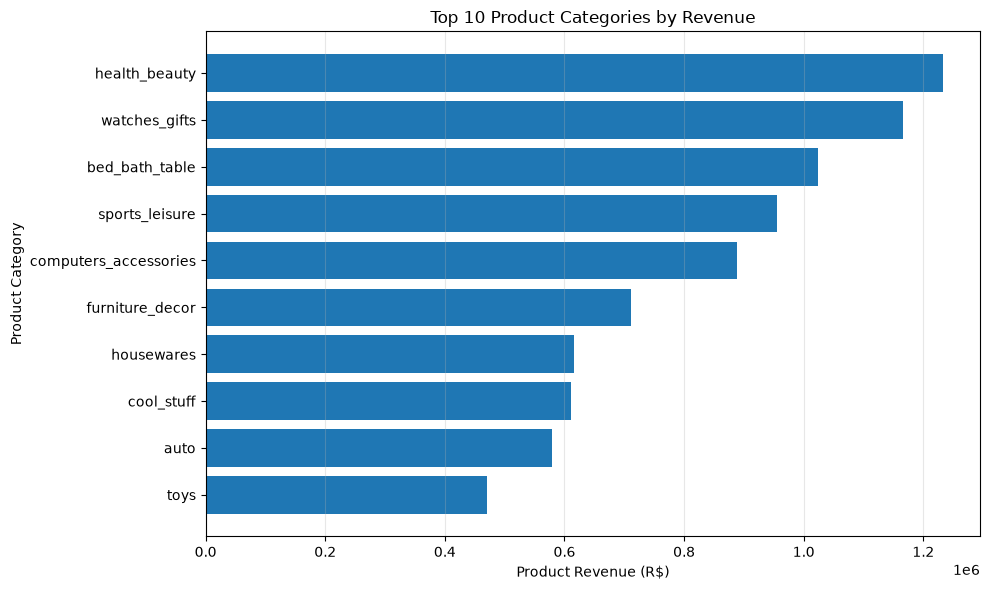

In [36]:
top_10_categories = category_revenue.head(10).sort_values(
    "product_revenue",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_categories["product_category_name_english"],
    top_10_categories["product_revenue"]
)

plt.xlabel("Product Revenue (R$)")
plt.ylabel("Product Category")
plt.title("Top 10 Product Categories by Revenue")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 6.8 Revenue per Category Order

Revenue per category order is calculated to evaluate how much product revenue
each category generates, on average, for an order containing that category.

This metric helps distinguish categories whose revenue performance is
associated primarily with higher order volume from those that generate more
revenue per category-containing order.

Because a single order may contain products from multiple categories, this
metric should be interpreted at the category level and is not equivalent to
the overall average order value (AOV).

In [37]:
category_revenue["revenue_per_category_order"] = (
    category_revenue["product_revenue"]
    / category_revenue["completed_orders"]
)

category_revenue[
    [
        "product_category_name_english",
        "product_revenue",
        "completed_orders",
        "items_sold",
        "revenue_per_category_order"
    ]
].head(10)

,product_category_name_english,product_revenue,completed_orders,items_sold,revenue_per_category_order
43,health_beauty,1233131.72,8647,9465,142.608040
71,watches_gifts,1166176.98,5495,5859,212.225110
7,bed_bath_table,1023434.76,9272,10953,110.379072
65,sports_leisure,954852.55,7530,8431,126.806448
15,computers_accessories,888724.61,6530,7644,136.098715
39,furniture_decor,711927.69,6307,8160,112.878974
49,housewares,615628.69,5743,6795,107.196359
20,cool_stuff,610204.10,3559,3718,171.453807
5,auto,578966.65,3810,4140,151.959751
69,toys,471286.48,3804,4030,123.892345


In [38]:
category_revenue[
    [
        "product_category_name_english",
        "revenue_per_category_order",
        "product_revenue",
        "completed_orders",
        "items_sold"
    ]
].sort_values(
    "revenue_per_category_order",
    ascending=False
).head(10)

,product_category_name_english,revenue_per_category_order,product_revenue,completed_orders,items_sold
14,computers,1235.503616,218684.14,177,199
64,small_appliances_home_oven_and_coffee,647.077222,46589.56,72,73
45,home_appliances_2,475.568062,107953.95,227,231
0,agro_industry_and_commerce,398.678531,70566.10,177,206
56,musical_instruments,301.662422,184315.74,611,651
63,small_appliances,300.088867,182754.12,609,658
34,fixed_telephony,260.920802,55315.21,212,255
19,construction_tools_safety,243.856730,38773.22,159,183
1,air_conditioning,216.762439,53323.56,246,289
57,office_furniture,213.839163,268154.31,1254,1668


#### Revenue per Category Order — Key Findings

Revenue per category order reveals meaningful differences in how the leading
product categories generate revenue.

Among the ten highest-revenue categories:

- **Watches & Gifts** generated approximately **R$212.23 per category-containing
  order**, compared with approximately **R$110.38** for **Bed, Bath & Table**.
  This helps explain why Watches & Gifts generated higher total product revenue
  despite appearing in substantially fewer completed orders.
- **Health & Beauty**, the highest-revenue category overall, generated
  approximately **R$142.61 per category-containing order** while also appearing
  in **8,647 completed orders**, combining relatively high revenue per order
  with substantial order volume.
- **Cool Stuff** and **Auto** also showed relatively high revenue per
  category-containing order, at approximately **R$171.45** and **R$151.96**,
  respectively.
- Categories such as **Bed, Bath & Table**, **Furniture & Decor**, and
  **Housewares** generated lower revenue per category-containing order but
  appeared across a comparatively large number of completed orders.

The results indicate that high category revenue can emerge through different
combinations of order volume and revenue per category-containing order.
Some leading categories benefit primarily from broad order participation,
while others combine meaningful order volume with higher revenue per order.

#### Interpretation of High Revenue-per-Order Categories

When all categories are ranked solely by revenue per category-containing
order, several relatively low-volume categories appear near the top.

For example, **Computers** generated approximately **R$1,235.50 per
category-containing order**, the highest value among all categories, but
appeared in only **177 completed orders**.

Similarly, **Small Appliances, Home Oven & Coffee** generated approximately
**R$647.08 per category-containing order** but appeared in only **72 completed
orders**.

Therefore, revenue per category order should not be interpreted independently
as a measure of overall category performance. Categories with high average
revenue but limited order volume may contribute substantially less total
revenue than categories that combine strong order volume with moderate or high
revenue per order.

### 6.9 Order Volume vs Revenue per Category Order

A scatter plot is used to examine the relationship between category order
volume and revenue per category-containing order.

Each point represents one product category:

- The **x-axis** represents the number of completed orders containing the
  category.
- The **y-axis** represents the average product revenue generated per
  category-containing order.

This comparison helps distinguish high-volume categories from categories that
generate relatively high revenue per order.

#### 6.9.1 Identify Extreme Categories

Categories with unusually high revenue per category-containing order are
examined separately because extreme values may affect the readability of the
overall scatter plot.

In [39]:
category_revenue[
    [
        "product_category_name_english",
        "completed_orders",
        "revenue_per_category_order",
        "product_revenue"
    ]
].sort_values(
    "revenue_per_category_order",
    ascending=False
).head(10)

,product_category_name_english,completed_orders,revenue_per_category_order,product_revenue
14,computers,177,1235.503616,218684.14
64,small_appliances_home_oven_and_coffee,72,647.077222,46589.56
45,home_appliances_2,227,475.568062,107953.95
0,agro_industry_and_commerce,177,398.678531,70566.10
56,musical_instruments,611,301.662422,184315.74
63,small_appliances,609,300.088867,182754.12
34,fixed_telephony,212,260.920802,55315.21
19,construction_tools_safety,159,243.856730,38773.22
1,air_conditioning,246,216.762439,53323.56
57,office_furniture,1254,213.839163,268154.31


In [40]:
category_revenue[
    ["completed_orders", "revenue_per_category_order"]
].describe()

,completed_orders,revenue_per_category_order
count,72.000000,72.000000
mean,1351.055556,160.446167
std,2209.046897,160.695813
min,2.000000,31.677917
25%,87.250000,86.795179
50%,244.000000,125.918085
75%,1481.000000,164.246578
max,9272.000000,1235.503616


#### Distribution Analysis — Key Findings

The category-level metrics show substantial variation across the 72 product
categories.

Completed orders range from **2 to 9,272**, with a median of **244 orders**.
The mean of approximately **1,351 orders** is substantially higher than the
median, indicating that a relatively small number of high-volume categories
pull the average upward.

Revenue per category-containing order ranges from approximately **R$31.68 to
R$1,235.50**, with a median of approximately **R$125.92**. The mean of
approximately **R$160.45** is also higher than the median because several
categories generate unusually high revenue per order.

Given these skewed distributions, the median is used rather than the mean to
define relative high and low category performance in the quadrant analysis.

#### 6.9.2 Category Performance Quadrants

Product categories are classified into four performance groups using the
median completed-order volume and median revenue per category-containing order
as relative benchmarks.

The median thresholds are:

- **Completed orders:** 244
- **Revenue per category order:** approximately R$125.92

The four groups are defined as:

1. **High Volume / High Value** — at or above the median in both metrics
2. **High Volume / Low Value** — at or above the median in order volume but
   below the median in revenue per category order
3. **Low Volume / High Value** — below the median in order volume but at or
   above the median in revenue per category order
4. **Low Volume / Low Value** — below the median in both metrics

These groups represent relative category positioning within the Olist dataset
rather than fixed business-performance standards.

In [41]:
median_orders = category_revenue["completed_orders"].median()
median_revenue_per_order = (
    category_revenue["revenue_per_category_order"].median()
)

print(f"Median completed orders: {median_orders:.0f}")
print(
    "Median revenue per category order:",
    f"R${median_revenue_per_order:,.2f}"
)

Median completed orders: 244
Median revenue per category order: R$125.92


In [42]:
def classify_category(row):
    high_volume = row["completed_orders"] >= median_orders
    high_value = (
        row["revenue_per_category_order"]
        >= median_revenue_per_order
    )

    if high_volume and high_value:
        return "High Volume / High Value"
    elif high_volume and not high_value:
        return "High Volume / Low Value"
    elif not high_volume and high_value:
        return "Low Volume / High Value"
    else:
        return "Low Volume / Low Value"


category_revenue["performance_group"] = (
    category_revenue.apply(classify_category, axis=1)
)

In [43]:
category_revenue["performance_group"].value_counts()

performance_group
High Volume / High Value    20
Low Volume / Low Value      20
High Volume / Low Value     16
Low Volume / High Value     16
Name: count, dtype: int64

In [44]:
category_revenue[
    [
        "product_category_name_english",
        "completed_orders",
        "revenue_per_category_order",
        "product_revenue",
        "performance_group"
    ]
].sort_values(
    "product_revenue",
    ascending=False
).head(15)

,product_category_name_english,completed_orders,revenue_per_category_order,product_revenue,performance_group
43,health_beauty,8647,142.608040,1233131.72,High Volume / High Value
71,watches_gifts,5495,212.225110,1166176.98,High Volume / High Value
7,bed_bath_table,9272,110.379072,1023434.76,High Volume / Low Value
65,sports_leisure,7530,126.806448,954852.55,High Volume / High Value
15,computers_accessories,6530,136.098715,888724.61,High Volume / High Value
39,furniture_decor,6307,112.878974,711927.69,High Volume / Low Value
49,housewares,5743,107.196359,615628.69,High Volume / Low Value
20,cool_stuff,3559,171.453807,610204.10,High Volume / High Value
5,auto,3810,151.959751,578966.65,High Volume / High Value
69,toys,3804,123.892345,471286.48,High Volume / Low Value


#### Category Performance Classification — Key Findings

The median-based classification separates the 72 product categories into four
performance groups:

- **20 categories** are classified as High Volume / High Value.
- **16 categories** are classified as High Volume / Low Value.
- **16 categories** are classified as Low Volume / High Value.
- **20 categories** are classified as Low Volume / Low Value.

Among the leading revenue categories, different performance patterns are
clearly visible.

**Health & Beauty**, **Watches & Gifts**, **Sports & Leisure**, and
**Computers & Accessories** fall into the High Volume / High Value group,
combining above-median order participation with above-median revenue per
category-containing order.

In contrast, **Bed, Bath & Table**, **Furniture & Decor**, **Housewares**, and
**Toys** fall into the High Volume / Low Value group. These categories generate
substantial total revenue primarily alongside broad order participation,
despite below-median revenue per category-containing order.

The classification demonstrates that leading categories can reach high total
revenue through different combinations of order volume and revenue per order.

#### 6.9.3 Category Performance Quadrant Visualization

The category performance groups are visualized using completed-order volume
and revenue per category-containing order.

Median reference lines divide the chart into four relative performance
quadrants. Selected categories are labeled to illustrate representative
business patterns without overcrowding the visualization.

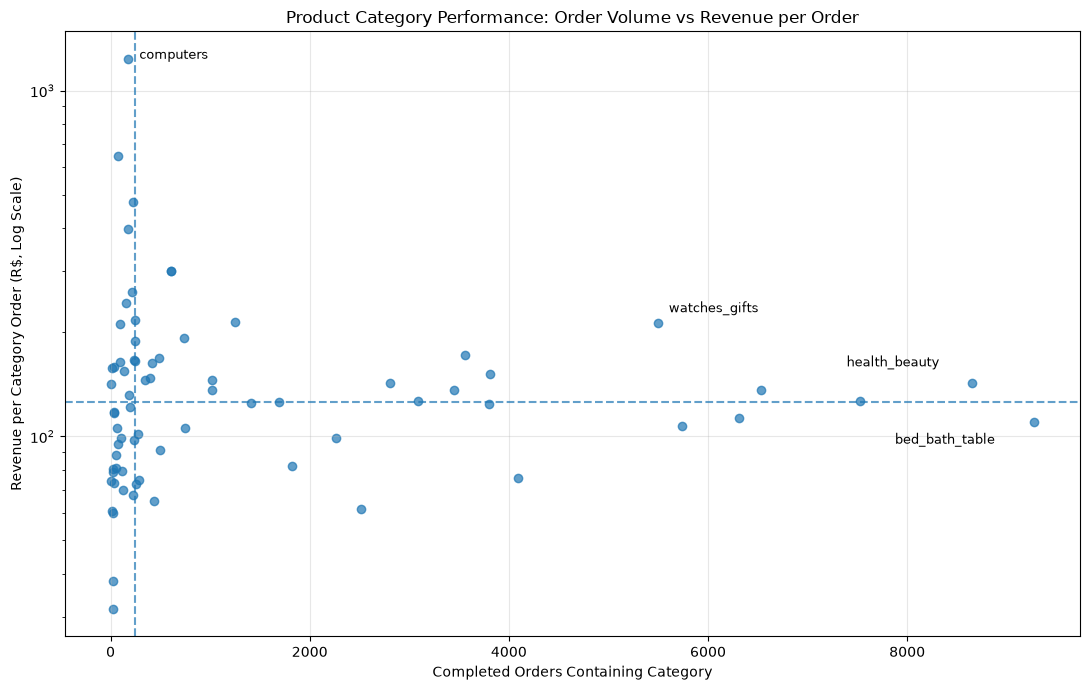

In [45]:
plt.figure(figsize=(11, 7))

plt.scatter(
    category_revenue["completed_orders"],
    category_revenue["revenue_per_category_order"],
    alpha=0.7
)

# Median reference lines
plt.axvline(
    median_orders,
    linestyle="--",
    alpha=0.7
)

plt.axhline(
    median_revenue_per_order,
    linestyle="--",
    alpha=0.7
)

# Use logarithmic scale to improve visibility
# while retaining high-value categories.
plt.yscale("log")

# Selected representative categories
label_offsets = {
    "computers": (8, 0),
    "watches_gifts": (8, 8),
    "health_beauty": (-90, 12),
    "bed_bath_table": (-100, -16)
}

for category, offset in label_offsets.items():

    row = category_revenue[
        category_revenue["product_category_name_english"] == category
    ].iloc[0]

    plt.annotate(
        category,
        (
            row["completed_orders"],
            row["revenue_per_category_order"]
        ),
        xytext=offset,
        textcoords="offset points",
        fontsize=9
    )

plt.xlabel("Completed Orders Containing Category")
plt.ylabel("Revenue per Category Order (R$, Log Scale)")
plt.title(
    "Product Category Performance: "
    "Order Volume vs Revenue per Order"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Quadrant Visualization — Key Findings

The scatter plot shows substantial differences in how product categories
generate revenue.

**Watches & Gifts** and **Health & Beauty** are positioned in the High Volume /
High Value quadrant, combining above-median order participation with
above-median revenue per category-containing order.

In contrast, **Bed, Bath & Table** is positioned in the High Volume / Low Value
quadrant. Its strong total revenue is therefore associated with broad order
participation despite lower revenue per category-containing order.

**Computers** represents a different pattern. It generated approximately
**R$1,235.50 per category-containing order**, but appeared in only **177
completed orders**, placing it in the Low Volume / High Value group.

A logarithmic scale is used for the y-axis because several high-value
categories, particularly Computers, would otherwise compress the majority of
categories near the bottom of the visualization. The transformation improves
visual readability while preserving all category observations.

Overall, the quadrant analysis demonstrates that high total category revenue
can be associated with different combinations of order volume and revenue per
category-containing order.

### 6.10 Product Category Performance Summary

Product category performance varies substantially across Olist's completed
sales, with leading categories generating revenue through different
combinations of order volume and revenue per category-containing order.

Key findings include:

- **Health & Beauty** generated the highest product revenue at approximately
  **R$1.23 million**, followed by **Watches & Gifts** at approximately
  **R$1.17 million** and **Bed, Bath & Table** at approximately **R$1.02
  million**.
- The **top 5 categories** contributed approximately **39.83%** of total
  product revenue, while the **top 10 categories** accounted for approximately
  **62.43%**. Revenue is therefore meaningfully concentrated among leading
  categories, while a substantial share remains distributed across the rest
  of the marketplace.
- Revenue ranking does not simply follow order volume. **Watches & Gifts**
  generated approximately **R$212.23 per category-containing order**, compared
  with approximately **R$110.38** for **Bed, Bath & Table**, helping explain
  why Watches & Gifts generated higher total revenue despite appearing in
  substantially fewer completed orders.
- The median-based quadrant analysis identifies different category performance
  patterns. **Health & Beauty** and **Watches & Gifts** combine above-median
  order volume with above-median revenue per category-containing order, while
  **Bed, Bath & Table** combines high order volume with below-median revenue
  per category-containing order.
- Some categories exhibit high revenue per order but limited scale.
  **Computers**, for example, generated approximately **R$1,235.50 per
  category-containing order** but appeared in only **177 completed orders**.
  High average revenue per order should therefore not be interpreted
  independently as evidence of strong overall category performance.

Overall, the analysis shows that Olist's leading product categories follow
different revenue patterns. Some categories achieve strong revenue through
broad order participation, while others combine meaningful order volume with
higher revenue per category-containing order. Evaluating both dimensions
provides a more complete view of category performance than revenue ranking
alone.

## 7. Seller Performance

This section evaluates sales performance across sellers to identify which
sellers contribute the most to Olist's completed-order product revenue and
whether seller performance is concentrated among a relatively small group of
sellers.

The analysis focuses on:

- Product revenue by seller
- Completed orders by seller
- Number of items sold
- Revenue contribution by seller
- Revenue concentration among leading sellers
- Revenue per seller order

Only completed-order sales are included to maintain consistency with the core
sales metrics defined earlier.

### 7.1 Validate Seller Data

Before analyzing seller performance, the seller dataset is validated to
confirm that each `seller_id` represents a unique seller record.

This ensures that seller information can be safely joined to the completed
item-level sales dataset without introducing row multiplication.

In [46]:
print("Seller records:", len(sellers))
print("Unique seller IDs:", sellers["seller_id"].nunique())
print(
    "Duplicate seller IDs:",
    sellers["seller_id"].duplicated().sum()
)

Seller records: 3095
Unique seller IDs: 3095
Duplicate seller IDs: 0


#### Seller Key Validation — Key Findings

The seller dataset contains **3,095 seller records** and **3,095 unique seller
IDs**, with no duplicate `seller_id` values.

This confirms that each seller maps to a single seller record and that
`seller_id` can be safely used as the key for seller-level analysis or
many-to-one joins with item-level sales data.

### 7.2 Seller Coverage in Completed Sales

Seller participation in completed sales is examined before evaluating seller
performance.

The analysis compares the total number of sellers in the seller dataset with
the number of unique sellers appearing in completed item-level sales. This
helps distinguish registered sellers from sellers with observed completed
sales activity.

In [47]:
total_sellers = sellers["seller_id"].nunique()
active_sellers = sales_items["seller_id"].nunique()

inactive_sellers = total_sellers - active_sellers

seller_coverage_pct = (
    active_sellers / total_sellers * 100
)

print("Total sellers:", total_sellers)
print("Sellers with completed sales:", active_sellers)
print("Sellers without completed sales:", inactive_sellers)
print(
    "Seller coverage:",
    f"{seller_coverage_pct:.2f}%"
)

Total sellers: 3095
Sellers with completed sales: 2970
Sellers without completed sales: 125
Seller coverage: 95.96%


#### Seller Coverage — Key Findings

Of the **3,095 sellers** in the seller dataset, **2,970 sellers** appear in at
least one completed-order sales record, representing approximately **95.96%**
of all sellers.

The remaining **125 sellers** do not appear in the completed-sales dataset.

For this analysis, sellers with completed sales refer specifically to sellers
with at least one item associated with a completed order during the observed
dataset period. This should not be interpreted as a measure of whether a seller
remained operational or active at the end of the dataset period.

### 7.3 Seller Revenue Performance

Completed item-level sales are aggregated by seller to evaluate differences in
seller sales performance.

Three core metrics are calculated for each seller:

- **Product Revenue:** Total product revenue generated by the seller
- **Completed Orders:** Number of distinct completed orders containing items
  sold by the seller
- **Items Sold:** Number of completed item-level sales records associated with
  the seller

Because a single order may contain items from multiple sellers, seller-level
completed-order counts are not additive across sellers.

In [48]:
seller_performance = (
    sales_items
    .groupby("seller_id")
    .agg(
        product_revenue=("price", "sum"),
        completed_orders=("order_id", "nunique"),
        items_sold=("order_id", "size")
    )
    .reset_index()
    .sort_values("product_revenue", ascending=False)
)

seller_performance.head(10)

,seller_id,product_revenue,completed_orders,items_sold
834,4869f7a5dfa277a7dca6462dcf3b52b2,226987.93,1124,1148
982,53243585a1d6dc2643021fd1853d8905,217940.44,348,400
858,4a3ca9315b744ce9f8e9374361493884,196882.12,1772,1949
2903,fa1c13f2614d7b5c4749cbc52fecda94,190917.14,578,579
1480,7c67e1448b00f6e969d365cea6b010ab,186570.05,973,1355
1504,7e93a43ef30c4f03f38b393420bc753a,165981.49,319,322
2543,da8622b14eb17ae2831f4ac5b9dab84a,159816.87,1311,1548
1450,7a67c85e85bb2ce8582c35f2203ad736,139658.69,1145,1155
188,1025f0e2d44d7041d6cf58b6550e0bfa,138208.56,910,1420
1758,955fee9216a65b617aa5c0531780ce60,131836.71,1261,1472


#### 7.3.1 Seller Revenue Validation

Seller-level product revenue is reconciled with the completed item-level sales
dataset to confirm that the aggregation preserves the full product revenue
without duplication or loss.

In [49]:
total_seller_revenue = seller_performance["product_revenue"].sum()
sales_product_revenue = sales_items["price"].sum()

print(
    "Total seller revenue:",
    f"R${total_seller_revenue:,.2f}"
)

print(
    "Sales item product revenue:",
    f"R${sales_product_revenue:,.2f}"
)

print(
    "Revenue difference:",
    f"R${total_seller_revenue - sales_product_revenue:,.2f}"
)

Total seller revenue: R$13,221,498.11
Sales item product revenue: R$13,221,498.11
Revenue difference: R$0.00


#### Seller Revenue Validation — Key Findings

Seller-level product revenue totals **R$13,221,498.11**, exactly matching the
product revenue calculated from the completed item-level sales dataset.

The revenue difference is **R$0.00**, confirming that the seller-level
aggregation preserves the full completed-sales product revenue without
duplication or loss.

The leading sellers also show noticeable differences between revenue and
order volume. Some sellers generate high product revenue from relatively
fewer completed orders, suggesting that seller performance may reflect
different combinations of sales volume and revenue per order.

### 7.4 Seller Revenue Concentration

Seller revenue concentration is analyzed to determine how much of Olist's
completed-sales product revenue is generated by its leading sellers.

Because **2,970 sellers** appear in completed sales, concentration is evaluated
using both fixed seller counts and a proportional threshold:

- Top 10 sellers
- Top 50 sellers
- Top 100 sellers
- Top 10% of sellers by product revenue

This provides a broader view of whether marketplace revenue is distributed
across many sellers or concentrated among a relatively small group.

#### 7.4.1 Seller Revenue Concentration Metrics

In [50]:
seller_performance = seller_performance.sort_values(
    "product_revenue",
    ascending=False
).reset_index(drop=True)

total_revenue = seller_performance["product_revenue"].sum()
seller_count = len(seller_performance)

top_10_revenue_share = (
    seller_performance.head(10)["product_revenue"].sum()
    / total_revenue * 100
)

top_50_revenue_share = (
    seller_performance.head(50)["product_revenue"].sum()
    / total_revenue * 100
)

top_100_revenue_share = (
    seller_performance.head(100)["product_revenue"].sum()
    / total_revenue * 100
)

top_10_pct_count = int(np.ceil(seller_count * 0.10))

top_10_pct_revenue_share = (
    seller_performance
    .head(top_10_pct_count)["product_revenue"]
    .sum()
    / total_revenue * 100
)

print("Sellers with completed sales:", seller_count)
print("Top 10% seller count:", top_10_pct_count)
print()
print(
    "Top 10 sellers revenue share:",
    f"{top_10_revenue_share:.2f}%"
)
print(
    "Top 50 sellers revenue share:",
    f"{top_50_revenue_share:.2f}%"
)
print(
    "Top 100 sellers revenue share:",
    f"{top_100_revenue_share:.2f}%"
)
print(
    "Top 10% sellers revenue share:",
    f"{top_10_pct_revenue_share:.2f}%"
)

Sellers with completed sales: 2970
Top 10% seller count: 297

Top 10 sellers revenue share: 13.27%
Top 50 sellers revenue share: 33.20%
Top 100 sellers revenue share: 45.52%
Top 10% sellers revenue share: 67.11%


#### Seller Revenue Concentration — Key Findings

Seller revenue is meaningfully concentrated among the higher-revenue sellers.

The **top 10 sellers** generated approximately **13.27%** of completed-sales
product revenue, while the **top 50** and **top 100 sellers** accounted for
approximately **33.20%** and **45.52%**, respectively.

More broadly, the **top 10% of sellers by product revenue**, representing
**297 of the 2,970 sellers with completed sales**, generated approximately
**67.11%** of total product revenue.

These results indicate that seller revenue is unevenly distributed across the
marketplace. However, the relatively modest **13.27%** contribution from the
top 10 sellers suggests that revenue is not dominated by only a handful of
individual sellers.

#### 7.4.2 Cumulative Seller Revenue Distribution

A cumulative revenue curve is used to visualize how completed-sales product
revenue is distributed across sellers.

Sellers are ranked from highest to lowest product revenue. The cumulative
percentage of sellers is then compared with the cumulative percentage of
product revenue, providing a visual representation of seller revenue
concentration.

In [51]:
seller_concentration = (
    seller_performance
    .sort_values("product_revenue", ascending=False)
    .reset_index(drop=True)
    .copy()
)

seller_concentration["cumulative_revenue"] = (
    seller_concentration["product_revenue"].cumsum()
)

seller_concentration["cumulative_revenue_pct"] = (
    seller_concentration["cumulative_revenue"]
    / seller_concentration["product_revenue"].sum()
    * 100
)

seller_concentration["cumulative_seller_pct"] = (
    (seller_concentration.index + 1)
    / len(seller_concentration)
    * 100
)

seller_concentration[
    [
        "seller_id",
        "product_revenue",
        "cumulative_seller_pct",
        "cumulative_revenue_pct"
    ]
].head(10)

,seller_id,product_revenue,cumulative_seller_pct,cumulative_revenue_pct
0,4869f7a5dfa277a7dca6462dcf3b52b2,226987.93,0.03367,1.716809
1,53243585a1d6dc2643021fd1853d8905,217940.44,0.06734,3.365189
2,4a3ca9315b744ce9f8e9374361493884,196882.12,0.10101,4.854295
3,fa1c13f2614d7b5c4749cbc52fecda94,190917.14,0.13468,6.298285
4,7c67e1448b00f6e969d365cea6b010ab,186570.05,0.16835,7.709396
5,7e93a43ef30c4f03f38b393420bc753a,165981.49,0.20202,8.964787
6,da8622b14eb17ae2831f4ac5b9dab84a,159816.87,0.23569,10.173552
7,7a67c85e85bb2ce8582c35f2203ad736,139658.69,0.26936,11.229852
8,1025f0e2d44d7041d6cf58b6550e0bfa,138208.56,0.30303,12.275185
9,955fee9216a65b617aa5c0531780ce60,131836.71,0.33670,13.272323


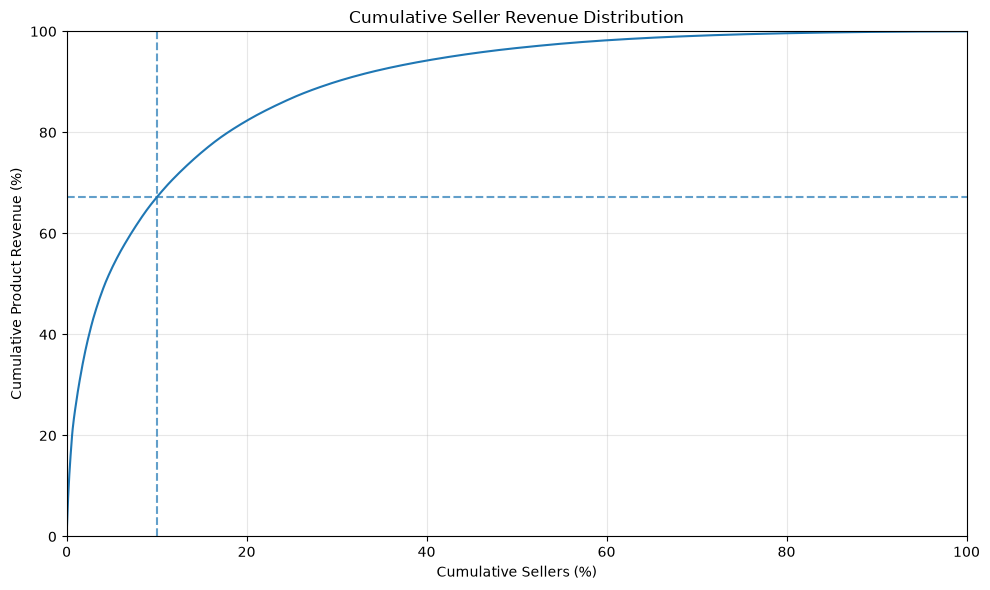

In [52]:
plt.figure(figsize=(10, 6))

plt.plot(
    seller_concentration["cumulative_seller_pct"],
    seller_concentration["cumulative_revenue_pct"]
)

plt.axvline(
    10,
    linestyle="--",
    alpha=0.7
)

plt.axhline(
    top_10_pct_revenue_share,
    linestyle="--",
    alpha=0.7
)

plt.xlabel("Cumulative Sellers (%)")
plt.ylabel("Cumulative Product Revenue (%)")
plt.title("Cumulative Seller Revenue Distribution")

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Cumulative Seller Revenue Distribution — Key Findings

The cumulative revenue distribution confirms that seller revenue is unevenly
distributed across the marketplace.

The curve rises rapidly among the highest-revenue sellers. The **top 10% of
sellers**, representing **297 sellers**, generated approximately **67.11%** of
completed-sales product revenue.

At the same time, the **top 10 individual sellers** accounted for approximately
**13.27%** of product revenue. This indicates that revenue concentration extends
across a broader group of high-performing sellers rather than being dominated
by only a few individual sellers.

Overall, the cumulative distribution supports the earlier concentration
analysis and shows that a relatively small share of sellers contributes a
disproportionately large share of marketplace product revenue.

### 7.5 Revenue per Seller Order

Total seller revenue may reflect both the number of completed orders associated
with a seller and the amount of product revenue generated from those orders.

To distinguish these effects, **revenue per seller order** is calculated as:

**Revenue per Seller Order = Seller Product Revenue / Completed Orders Containing Seller**

This metric represents the average product revenue generated by a seller per
completed order containing that seller's items.

It is not equivalent to Olist's overall Average Order Value (AOV), because a
single completed order may contain products from multiple sellers.

In [53]:
seller_performance["revenue_per_seller_order"] = (
    seller_performance["product_revenue"]
    / seller_performance["completed_orders"]
)

In [54]:
seller_performance[
    [
        "seller_id",
        "product_revenue",
        "completed_orders",
        "items_sold",
        "revenue_per_seller_order"
    ]
].head(10)

,seller_id,product_revenue,completed_orders,items_sold,revenue_per_seller_order
0,4869f7a5dfa277a7dca6462dcf3b52b2,226987.93,1124,1148,201.946557
1,53243585a1d6dc2643021fd1853d8905,217940.44,348,400,626.265632
2,4a3ca9315b744ce9f8e9374361493884,196882.12,1772,1949,111.107291
3,fa1c13f2614d7b5c4749cbc52fecda94,190917.14,578,579,330.306471
4,7c67e1448b00f6e969d365cea6b010ab,186570.05,973,1355,191.747225
5,7e93a43ef30c4f03f38b393420bc753a,165981.49,319,322,520.318150
6,da8622b14eb17ae2831f4ac5b9dab84a,159816.87,1311,1548,121.904554
7,7a67c85e85bb2ce8582c35f2203ad736,139658.69,1145,1155,121.972655
8,1025f0e2d44d7041d6cf58b6550e0bfa,138208.56,910,1420,151.877538
9,955fee9216a65b617aa5c0531780ce60,131836.71,1261,1472,104.549334


#### 7.5.1 Revenue per Seller Order Distribution

The distribution of revenue per seller order is examined before interpreting
the highest-value sellers.

This is important because sellers with very few completed orders may produce
extreme average values. Therefore, high revenue per seller order should be
interpreted together with seller order volume rather than as an independent
measure of overall seller performance.

In [55]:
seller_performance[
    [
        "completed_orders",
        "revenue_per_seller_order"
    ]
].describe()

,completed_orders,revenue_per_seller_order
count,2970.000000,2970.000000
mean,32.935690,195.520629
std,105.407111,368.473461
min,1.000000,6.000000
25%,2.000000,60.075000
50%,7.000000,105.143844
75%,22.000000,187.583944
max,1819.000000,6735.000000


In [56]:
seller_performance.sort_values(
    "revenue_per_seller_order",
    ascending=False
)[
    [
        "seller_id",
        "product_revenue",
        "completed_orders",
        "items_sold",
        "revenue_per_seller_order"
    ]
].head(10)

,seller_id,product_revenue,completed_orders,items_sold,revenue_per_seller_order
440,e3b4998c7a498169dc7bce44e6bb6277,6735.00,1,1,6735.000000
443,80ceebb4ee9b31afb6c6a916a574a1e2,6729.00,1,1,6729.000000
459,ee27a8f15b1dded4d213a468ba4eb391,6499.00,1,1,6499.000000
104,b37c4c02bda3161a7546a4e6d222d5b2,24075.00,4,15,6018.750000
734,585175ec331ea177fa47199e39a6170a,3549.00,1,1,3549.000000
444,abe021b01ba992245271b9aa422032df,6720.00,2,2,3360.000000
301,a00824eb9093d40e589b940ec45c4eb0,9399.97,3,3,3133.323333
170,e2a1ac9bf33e5549a2a4f834e70df2f8,14999.45,5,5,2999.890000
809,e908c0f3646e8b60375734a350d95d71,2951.00,1,1,2951.000000
513,d63c73efd41eb002280e7ec831424edb,5598.00,2,2,2799.000000


#### Revenue per Seller Order — Key Findings

Revenue per seller order varies substantially across sellers and exhibits a
strongly right-skewed distribution.

Across the **2,970 sellers with completed sales**, the median seller
participated in **7 completed orders**, while the mean was approximately
**32.94 orders**. This difference indicates that seller order volume is highly
uneven across the marketplace.

Revenue per seller order shows a similar pattern. The median was approximately
**R$105.14**, compared with a mean of **R$195.52**, while the maximum reached
**R$6,735.00**.

The highest revenue-per-order values are primarily associated with sellers
having very few completed orders. For example, each of the three
highest-ranked sellers by revenue per seller order participated in only
**one completed order**.

Therefore, revenue per seller order should not be interpreted independently as
a measure of overall seller performance. Seller order volume must also be
considered when comparing seller performance.

### 7.6 Seller Order Volume vs Revenue per Order

Seller performance is evaluated across two dimensions:

- **Completed Order Volume:** The number of distinct completed orders
  containing the seller's items
- **Revenue per Seller Order:** The average product revenue generated by the
  seller per completed order containing that seller's items

Examining these metrics together helps distinguish sellers that generate
revenue through high order volume from sellers that generate relatively high
revenue from fewer orders.

Because both metrics are strongly right-skewed, their distributions are
examined before selecting an appropriate visualization scale.

#### 7.6.1 Seller Order Volume and Revenue Relationships

In [57]:
seller_order_value_correlation = (
    seller_performance[
        [
            "completed_orders",
            "revenue_per_seller_order"
        ]
    ]
    .corr()
    .iloc[0, 1]
)

print(
    "Correlation between completed orders and revenue per seller order:",
    f"{seller_order_value_correlation:.4f}"
)

Correlation between completed orders and revenue per seller order: -0.0512


In [58]:
seller_revenue_order_correlation = (
    seller_performance[
        [
            "completed_orders",
            "product_revenue"
        ]
    ]
    .corr()
    .iloc[0, 1]
)

print(
    "Correlation between completed orders and product revenue:",
    f"{seller_revenue_order_correlation:.4f}"
)

Correlation between completed orders and product revenue: 0.8007


#### Seller Order Volume and Revenue — Key Findings

Seller completed-order volume shows a **strong positive correlation of 0.8007**
with seller product revenue. This indicates that sellers participating in more
completed orders generally tend to generate higher total product revenue.

In contrast, the correlation between completed-order volume and revenue per
seller order is approximately **-0.0512**, indicating almost no linear
relationship between the two metrics.

This suggests that higher seller order volume is not systematically associated
with higher revenue generated per seller-containing order. High-revenue sellers
may therefore achieve strong sales performance through different combinations
of order volume and revenue per seller order.

These correlations describe associations within the observed dataset and
should not be interpreted as evidence of causation.

#### 7.6.2 Seller Performance Visualization

A scatter plot is used to examine seller order volume and revenue per seller
order simultaneously.

Because both variables are strongly right-skewed and span wide ranges,
logarithmic scales are applied to both axes. This improves the visibility of
sellers across different sales volumes and revenue levels while preserving all
seller observations.

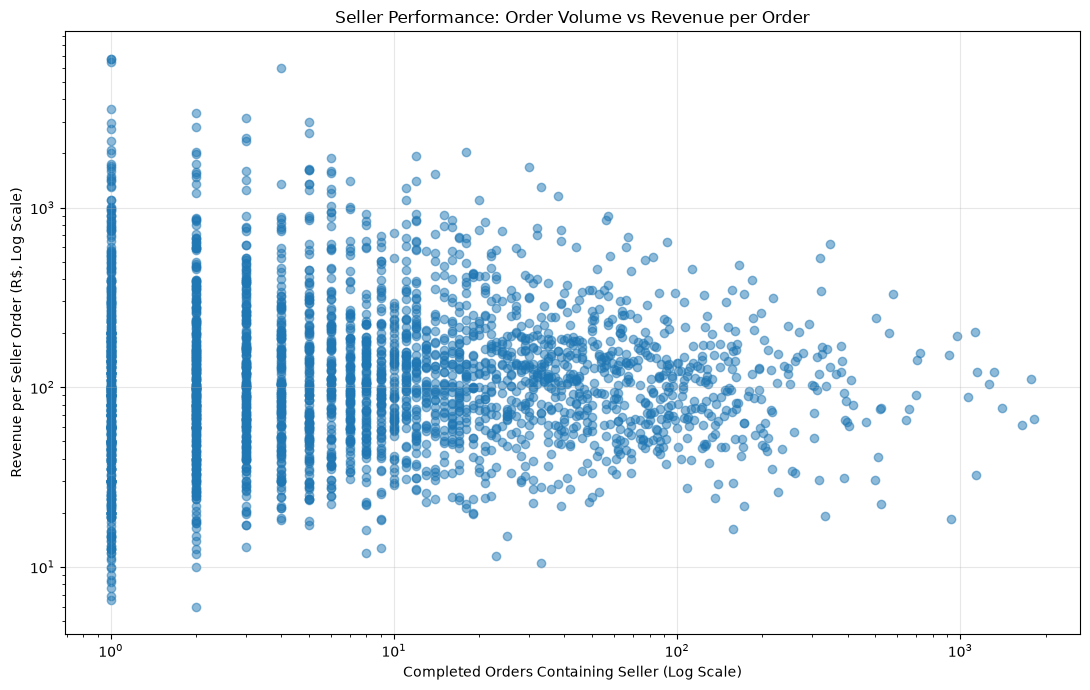

In [59]:
plt.figure(figsize=(11, 7))

plt.scatter(
    seller_performance["completed_orders"],
    seller_performance["revenue_per_seller_order"],
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Completed Orders Containing Seller (Log Scale)")
plt.ylabel("Revenue per Seller Order (R$, Log Scale)")
plt.title("Seller Performance: Order Volume vs Revenue per Order")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Seller Performance Visualization — Key Findings

The log-log scatter plot shows substantial variation in seller sales patterns
across the marketplace.

A large number of sellers participated in relatively few completed orders,
while a smaller group accumulated substantially higher order volumes. Among
low-volume sellers, revenue per seller order varies widely, including several
extreme high-value observations.

As seller order volume increases, revenue per seller order does not show a
clear upward pattern. This visual pattern is consistent with the near-zero
correlation of **-0.0512** between completed-order volume and revenue per
seller order.

Together with the strong **0.8007** correlation between completed orders and
total product revenue, the results suggest that seller revenue is more closely
associated with order volume than with systematically higher revenue per
seller order.

However, individual high-revenue sellers may achieve strong performance
through different combinations of order volume and revenue per seller order.

### 7.7 Seller Performance Summary

Seller performance across Olist's completed sales is uneven, with substantial
differences in revenue contribution, order volume, and revenue generated per
seller-containing order.

Key findings include:

- Of the **3,095 sellers** in the seller dataset, **2,970 sellers (95.96%)**
  appeared in at least one completed-order sales record during the observed
  dataset period.
- The highest-revenue seller generated approximately **R$226,987.93** in
  product revenue from **1,124 completed orders**.
- Seller revenue is meaningfully concentrated among higher-revenue sellers.
  The **top 10 sellers** generated approximately **13.27%** of product revenue,
  while the **top 100 sellers** accounted for approximately **45.52%**.
- More broadly, the **top 10% of sellers**, representing **297 sellers**,
  generated approximately **67.11%** of completed-sales product revenue.
  Revenue concentration therefore extends across a broader group of leading
  sellers rather than being dominated by only a few individual sellers.
- Completed-order volume has a **strong positive correlation of 0.8007** with
  seller product revenue, indicating that sellers participating in more
  completed orders generally tend to generate higher total product revenue.
- In contrast, completed-order volume has almost no linear relationship with
  revenue per seller order, with a correlation of approximately **-0.0512**.
- Revenue per seller order is strongly right-skewed. The median is
  approximately **R$105.14**, compared with a mean of **R$195.52**, and the
  highest values are primarily associated with sellers having very few
  completed orders.

Overall, seller product revenue is more closely associated with completed-order
volume than with systematically higher revenue per seller order. However,
individual sellers can achieve high revenue through different combinations of
sales volume and revenue generated per seller-containing order.

The results also show that marketplace revenue is unevenly distributed:
a relatively small share of sellers contributes a disproportionately large
share of completed-sales product revenue.

## 8. Overall Sales Analysis Summary

This section consolidates the major findings from the overall sales,
time-trend, product-category, and seller-performance analyses.

The objective is to translate the analytical results into a concise set of
business insights that describe Olist's sales growth, revenue structure, and
marketplace performance patterns.

### 8.1 Executive Summary

Olist generated approximately **R$13.22 million in completed-order product
revenue** from **96,478 completed orders**, with an overall Average Order Value
(AOV) of approximately **R$137.04**.

Sales activity expanded substantially during the main analysis period from
**January 2017 to August 2018**. Monthly product revenue increased from
approximately **R$111,798 in January 2017** to a peak of approximately
**R$987,765 in November 2017**, although the growth path included meaningful
month-to-month fluctuations.

The sales trend was more closely associated with changes in completed-order
volume than with sustained increases in AOV. Monthly product revenue and
completed orders showed a very strong positive correlation of **0.9927**, while
monthly AOV remained within a comparatively narrower range of approximately
**R$124 to R$149**.

Revenue was also unevenly distributed across both product categories and
sellers. The **top 10 product categories** contributed approximately **62.43%**
of product revenue, while the **top 10% of sellers** generated approximately
**67.11%** of completed-sales product revenue.

At the same time, high-revenue categories and sellers achieved strong
performance through different combinations of order volume and revenue
generated per order. This indicates that marketplace performance cannot be
fully understood from revenue rankings alone.

### 8.2 Key Business Insights

#### 1. Sales expansion was primarily associated with higher transaction volume

Olist experienced substantial sales expansion during the main analysis period,
but monthly AOV remained relatively stable compared with the large increase in
completed-order volume.

The strong **0.9927 correlation** between monthly completed orders and product
revenue indicates that marketplace growth was more closely associated with
increasing transaction volume than with sustained increases in revenue per
order.

#### 2. Revenue growth was strong but not continuous

Monthly revenue did not increase in a straight line. The strongest
month-over-month revenue growth occurred in **February 2017 at approximately
109.5%**, while the largest decline occurred in **December 2017 at
approximately -26.5%**.

This shows that the marketplace combined substantial overall expansion with
meaningful short-term volatility.

#### 3. Leading product categories follow different revenue models

The highest-revenue categories were **Health & Beauty**, **Watches & Gifts**,
and **Bed, Bath & Table**, but their revenue structures differed.

**Watches & Gifts** generated higher revenue per category-containing order,
while **Bed, Bath & Table** relied more heavily on broad order participation.

This demonstrates that strong category revenue can result from either higher
sales volume, higher revenue per category-containing order, or a combination of
both.

#### 4. Product revenue is concentrated but not dominated by only a few categories

The **top 5 product categories** contributed approximately **39.83%** of
completed-sales product revenue, while the **top 10 categories** contributed
approximately **62.43%**.

Revenue is therefore meaningfully concentrated among leading categories, while
a substantial portion remains distributed across the wider product portfolio.

#### 5. Seller revenue is unevenly distributed across the marketplace

Among the **2,970 sellers with completed sales**, the **top 10% of sellers**
generated approximately **67.11%** of total product revenue.

However, the **top 10 individual sellers** accounted for only approximately
**13.27%**, indicating that revenue concentration extends across a broader group
of higher-performing sellers rather than being dominated by only a handful of
individual sellers.

#### 6. Seller revenue is more closely associated with order volume than with revenue per order

Seller completed-order volume showed a strong positive correlation of
**0.8007** with total seller product revenue.

In contrast, completed-order volume had almost no linear relationship with
revenue per seller order, with a correlation of approximately **-0.0512**.

This indicates that high-revenue sellers may achieve strong performance through
different combinations of order volume and revenue generated per
seller-containing order.

### 8.3 Business Implications

The analysis suggests several practical considerations for marketplace
management and performance monitoring.

First, because overall revenue growth is closely associated with completed
order volume, operational and commercial strategies that support sustainable
transaction growth may be particularly important for marketplace expansion.

Second, category performance should be evaluated using both order volume and
revenue per category-containing order. Revenue ranking alone may hide
important differences between high-volume categories and higher-value
categories.

Third, seller performance should also be assessed across multiple dimensions.
The strong concentration of revenue among the top 10% of sellers indicates
that leading sellers represent an important share of marketplace revenue, while
the broader seller base still contributes a meaningful portion of total sales.

Finally, the substantial variation across categories and sellers suggests that
future analysis should combine sales performance with customer behavior,
delivery performance, and geographic patterns to better understand the factors
associated with marketplace growth and seller success.

In [60]:
seller_analysis_export = seller_performance.merge(
    sellers[
        [
            "seller_id",
            "seller_city",
            "seller_state"
        ]
    ],
    on="seller_id",
    how="left",
    validate="one_to_one"
)

seller_analysis_export = seller_analysis_export[
    [
        "seller_id",
        "seller_city",
        "seller_state",
        "completed_orders",
        "items_sold",
        "product_revenue",
        "revenue_per_seller_order"
    ]
]

seller_analysis_export.to_csv(
    "../data/processed/seller_analysis.csv",
    index=False
)

print("Exported sellers:", len(seller_analysis_export))
print("Unique sellers:", seller_analysis_export["seller_id"].nunique())
print("Missing seller IDs:", seller_analysis_export["seller_id"].isna().sum())
print("Missing seller states:", seller_analysis_export["seller_state"].isna().sum())

seller_analysis_export.head()

Exported sellers: 2970
Unique sellers: 2970
Missing seller IDs: 0
Missing seller states: 0


,seller_id,seller_city,seller_state,completed_orders,items_sold,product_revenue,revenue_per_seller_order
0,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,1124,1148,226987.93,201.946557
1,53243585a1d6dc2643021fd1853d8905,lauro de freitas,BA,348,400,217940.44,626.265632
2,4a3ca9315b744ce9f8e9374361493884,ibitinga,SP,1772,1949,196882.12,111.107291
3,fa1c13f2614d7b5c4749cbc52fecda94,sumare,SP,578,579,190917.14,330.306471
4,7c67e1448b00f6e969d365cea6b010ab,itaquaquecetuba,SP,973,1355,186570.05,191.747225
